WEEK 4 - DAY 3: CORRELATION & REGRESSION

Dataset loaded successfully.
Number of transactions: 1000

Columns:
['Transaction_ID', 'Date', 'Customer_ID', 'Product_ID', 'Category', 'Units', 'Unit_Price', 'Discount_Pct', 'Channel', 'City', 'Return_Flag', 'Revenue']

PEARSON CORRELATION
               Units  Unit_Price  Discount_Pct  Revenue
Units         1.0000     -0.0273        0.0584   0.6400
Unit_Price   -0.0273      1.0000       -0.0632   0.6775
Discount_Pct  0.0584     -0.0632        1.0000  -0.0825
Revenue       0.6400      0.6775       -0.0825   1.0000

SPEARMAN CORRELATION
               Units  Unit_Price  Discount_Pct  Revenue
Units         1.0000     -0.0274        0.0629   0.6538
Unit_Price   -0.0274      1.0000       -0.0657   0.6905
Discount_Pct  0.0629     -0.0657        1.0000  -0.0700
Revenue       0.6538      0.6905       -0.0700   1.0000

Correlation results saved successfully.


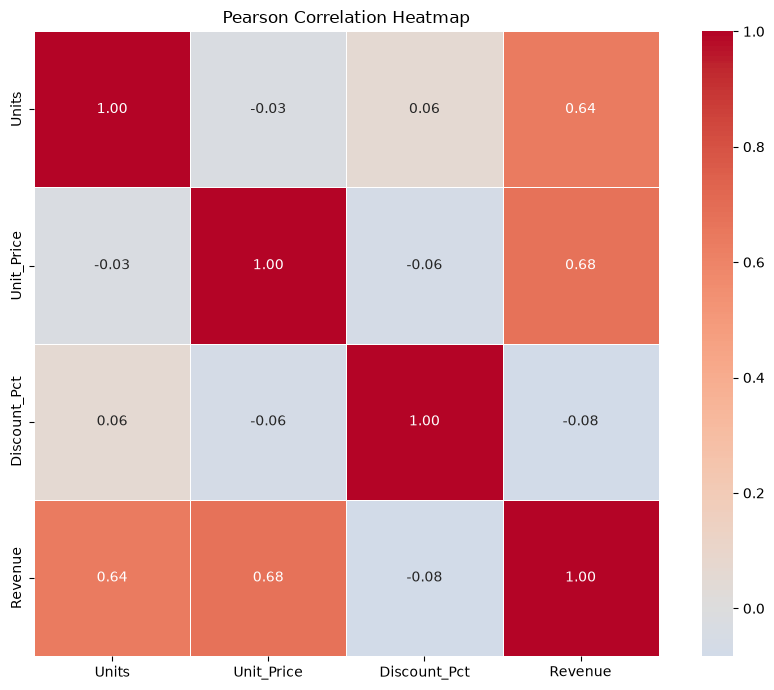

Correlation heatmap saved successfully.


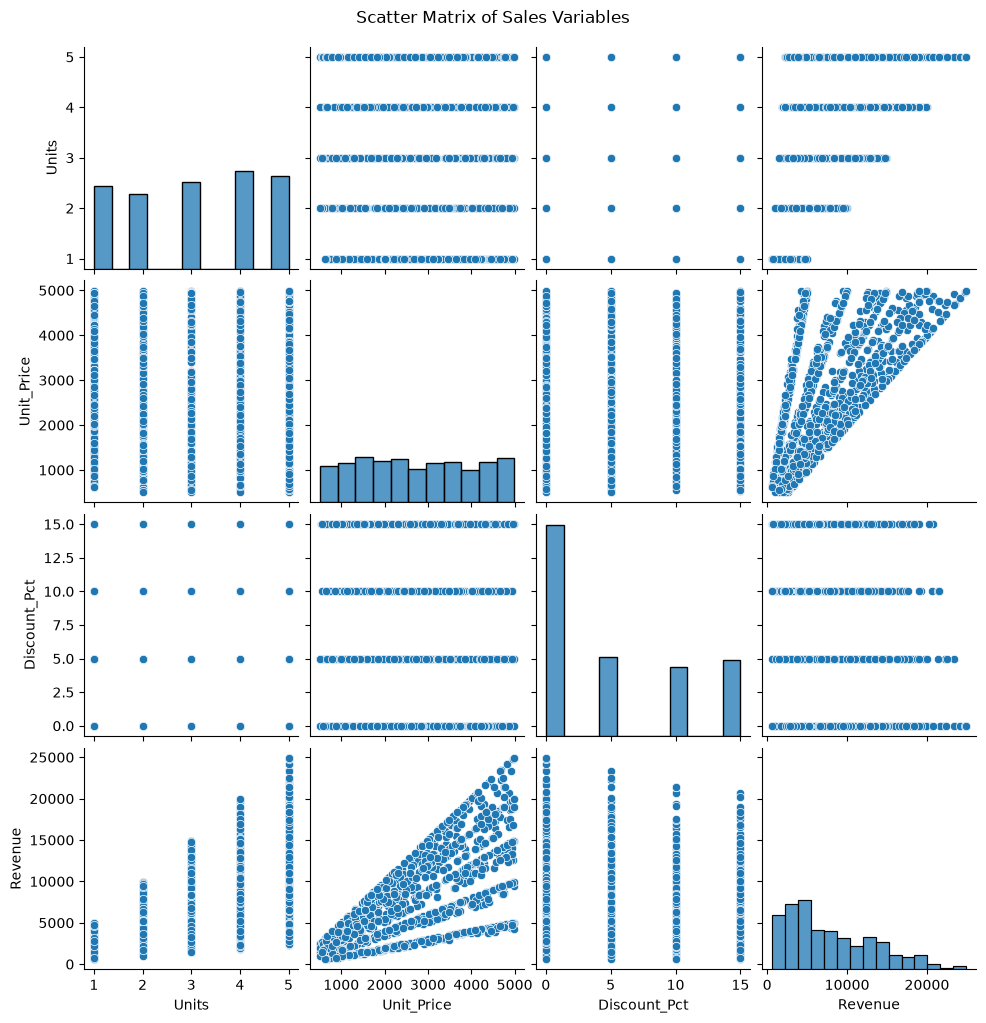

Scatter matrix saved successfully.

SIMPLE LINEAR REGRESSION
Intercept: 182.5892
Coefficient for Unit_Price: 2.8668

Regression equation: Revenue = 182.5892 + (2.8668 × Unit_Price)

REGRESSION MODEL METRICS
R² Score: 0.4446
Mean Absolute Error (MAE): 3247.90
Root Mean Squared Error (RMSE): 4095.17

Regression metrics saved successfully.


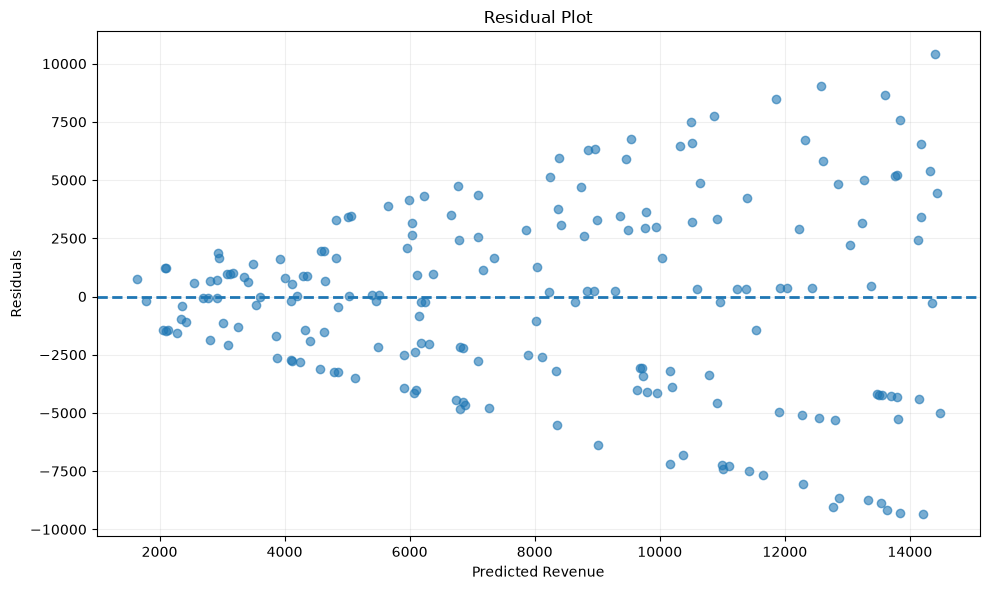

Residual plot saved successfully.

RESIDUAL ANALYSIS
Mean residual: -162.9935
Residual standard deviation: 4102.1980
Minimum residual: -9320.76
Maximum residual: 10402.16

MODEL ASSUMPTION CHECK
Mean residual is close to zero.

Residual interpretation:
- Residuals should generally be scattered around zero.
- A random pattern around zero supports the linearity assumption.
- A funnel-shaped pattern may indicate non-constant variance.
- Large isolated residuals may indicate potential outliers.

Model summary:
- R²: 0.4446
- MAE: 3247.90
- RMSE: 4095.17
- Mean residual: -162.9935

Correlation-regression analysis completed successfully.


In [1]:
# Week 4 - Day 3: Correlation & Regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
file_path = "Checkpoint-2/data/da_sales_transactions.csv"
df = pd.read_csv(file_path)

# Create Revenue
df["Revenue"] = (
    df["Units"]
    * df["Unit_Price"]
    * (1 - df["Discount_Pct"] / 100)
)

print("=" * 60)
print("WEEK 4 - DAY 3: CORRELATION & REGRESSION")
print("=" * 60)

print("\nDataset loaded successfully.")
print(f"Number of transactions: {len(df)}")

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# TASK 1: PEARSON AND SPEARMAN CORRELATION
# ============================================================

# Select numeric variables for correlation analysis
correlation_data = df[
    ["Units", "Unit_Price", "Discount_Pct", "Revenue"]
].dropna()

# Pearson correlation
pearson_corr = correlation_data.corr(method="pearson")

# Spearman correlation
spearman_corr = correlation_data.corr(method="spearman")

print("\n" + "=" * 60)
print("PEARSON CORRELATION")
print("=" * 60)
print(pearson_corr.round(4))

print("\n" + "=" * 60)
print("SPEARMAN CORRELATION")
print("=" * 60)
print(spearman_corr.round(4))

# Save correlation results
pearson_corr.to_csv(
    "Week 04/Day 3/pearson_correlation.csv"
)

spearman_corr.to_csv(
    "Week 04/Day 3/spearman_correlation.csv"
)

print("\nCorrelation results saved successfully.")

# ============================================================
# TASK 2: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "Week 04/Day 3/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correlation heatmap saved successfully.")

# ============================================================
# TASK 2: SCATTER MATRIX
# ============================================================

scatter_data = df[
    ["Units", "Unit_Price", "Discount_Pct", "Revenue"]
].dropna()

sns.pairplot(
    scatter_data,
    diag_kind="hist"
)

plt.suptitle(
    "Scatter Matrix of Sales Variables",
    y=1.02
)

plt.savefig(
    "Week 04/Day 3/scatter_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Scatter matrix saved successfully.")

# ============================================================
# TASK 3: SIMPLE LINEAR REGRESSION
# ============================================================

# Independent variable (X) and dependent variable (y)
X = df[["Unit_Price"]]
y = df["Revenue"]

# Remove missing values
regression_data = pd.concat([X, y], axis=1).dropna()

X = regression_data[["Unit_Price"]]
y = regression_data["Revenue"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Model equation
intercept = model.intercept_
coefficient = model.coef_[0]

print("\n" + "=" * 60)
print("SIMPLE LINEAR REGRESSION")
print("=" * 60)

print(f"Intercept: {intercept:.4f}")
print(f"Coefficient for Unit_Price: {coefficient:.4f}")

print(
    f"\nRegression equation:"
    f" Revenue = {intercept:.4f} + "
    f"({coefficient:.4f} × Unit_Price)"
)

# ============================================================
# TASK 4: REGRESSION MODEL METRICS
# ============================================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 60)
print("REGRESSION MODEL METRICS")
print("=" * 60)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Save metrics
metrics_summary = pd.DataFrame({
    "Metric": ["R2", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

metrics_summary.to_csv(
    "Week 04/Day 3/regression_metrics.csv",
    index=False
)

print("\nRegression metrics saved successfully.")

# ============================================================
# TASK 5: RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "Week 04/Day 3/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual plot saved successfully.")

# Basic residual diagnostics
print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS")
print("=" * 60)

print(f"Mean residual: {residuals.mean():.4f}")
print(f"Residual standard deviation: {residuals.std():.4f}")
print(f"Minimum residual: {residuals.min():.2f}")
print(f"Maximum residual: {residuals.max():.2f}")

# ============================================================
# MODEL ASSUMPTION INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("MODEL ASSUMPTION CHECK")
print("=" * 60)

if abs(residuals.mean()) < 500:
    print("Mean residual is close to zero.")
else:
    print("Mean residual is not exactly zero, but is relatively small.")

print("\nResidual interpretation:")
print("- Residuals should generally be scattered around zero.")
print("- A random pattern around zero supports the linearity assumption.")
print("- A funnel-shaped pattern may indicate non-constant variance.")
print("- Large isolated residuals may indicate potential outliers.")

print("\nModel summary:")
print(f"- R²: {r2:.4f}")
print(f"- MAE: {mae:.2f}")
print(f"- RMSE: {rmse:.2f}")
print(f"- Mean residual: {residuals.mean():.4f}")

print("\nCorrelation-regression analysis completed successfully.")